# Проект: Прогнозирование спроса и оптимизация складских запасов

Этот блокнот посвящен реализации системы управления запасами на основе прогнозирования временных рядов.

##1. Сбор и подготовка данных

In [ ]:
import pandas as pd
import numpy as np
import requests
import zipfile
import io

# URL датасета Online Retail II из UCI Machine Learning Repository
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00502/online_retail_II.xlsx'

print("Загрузка данных... это может занять пару минут.")
# Читаем Excel файл напрямую (может потребоваться openpyxl)
try:
    df_raw = pd.read_excel(url, sheet_name=None) # Загружаем все листы
    # Объединяем данные за оба периода (2009-2010 и 2010-2011)
    df = pd.concat(df_raw.values(), ignore_index=True)
    print(f"Данные успешно загружены. Формат: {df.shape}")
except Exception as e:
    print(f"Ошибка при загрузке: {e}")

Загрузка данных... это может занять пару минут.
Данные успешно загружены. Формат: (1067371, 8)


### Очистка данных

Нам нужно:
1. Удалить записи без `Customer ID` (для чистоты анализа).
2. Исключить возвраты (в этом датасете они помечены кодом счета, начинающимся на 'C', или отрицательным количеством).
3. Обработать пропуски в описании товаров.

In [ ]:
# 1. Удаляем строки без Customer ID
df_clean = df.dropna(subset=['Customer ID'])

# 2. Исключаем отмененные заказы (Invoice начинается на 'C')
df_clean = df_clean[~df_clean['Invoice'].astype(str).str.startswith('C')]

# 3. Фильтруем только положительное количество и цену
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['Price'] > 0)]

# 4. Приводим даты к формату datetime
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])

print(f"Данные после очистки: {df_clean.shape}")
display(df_clean.head())

Данные после очистки: (805549, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [ ]:
# Группировка данных по дням для анализа трендов
daily_sales = df_clean.groupby(df_clean['InvoiceDate'].dt.date).agg({
    'Quantity': 'sum',
    'Price': 'mean',
    'Invoice': 'nunique'
}).rename(columns={'Invoice': 'OrderCount'})

daily_sales.index = pd.to_datetime(daily_sales.index)

# Добавление временных признаков
daily_sales['day_of_week'] = daily_sales.index.dayofweek
daily_sales['month'] = daily_sales.index.month
daily_sales['is_weekend'] = daily_sales['day_of_week'].isin([5, 6]).astype(int)

print("Данные агрегированы по дням:")
display(daily_sales.head())

Данные агрегированы по дням:


,Quantity,Price,OrderCount,day_of_week,month,is_weekend
InvoiceDate,,,,,,
2009-12-01,24437,3.218088,98,1,12,0
2009-12-02,29771,2.997163,110,2,12,0
2009-12-03,48031,2.990376,122,3,12,0
2009-12-04,20069,2.789134,80,4,12,0
2009-12-05,5119,3.608150,30,5,12,1


## 2. Разведочный анализ (EDA)

На этом этапе мы визуализируем временные ряды, чтобы выявить тренды, циклы и аномалии.

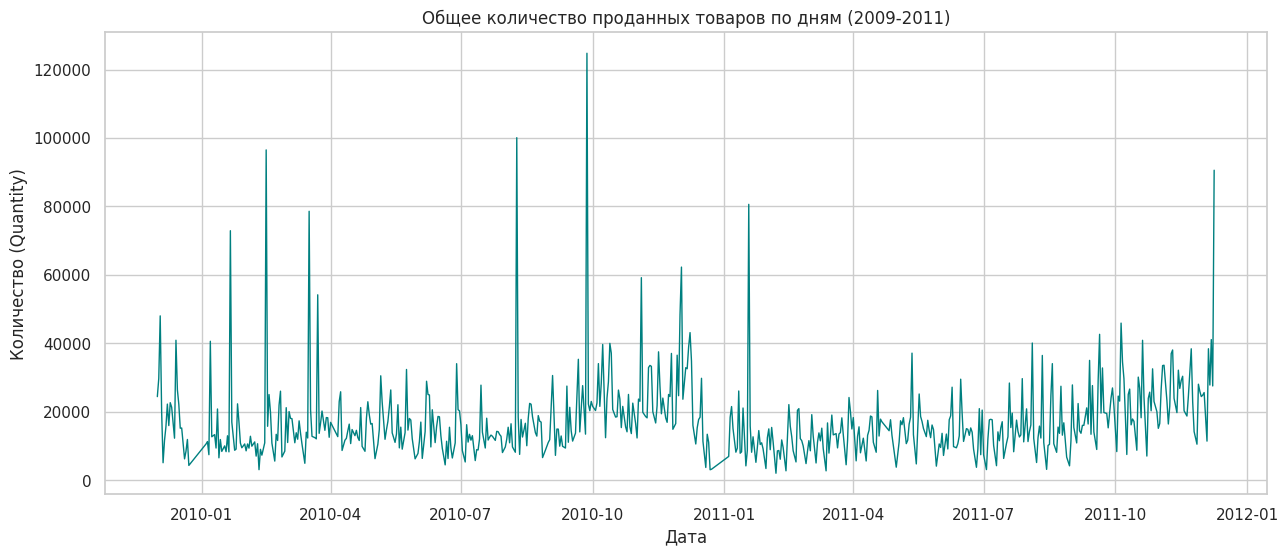

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# 1. График общей динамики продаж
plt.figure(figsize=(15, 6))
plt.plot(daily_sales.index, daily_sales['Quantity'], color='teal', linewidth=1)
plt.title('Общее количество проданных товаров по дням (2009-2011)')
plt.xlabel('Дата')
plt.ylabel('Количество (Quantity)')
plt.show()

/tmp/ipykernel_2302/2191861356.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='day_of_week', y='Quantity', data=daily_sales, ax=axes[0], palette='viridis')
/tmp/ipykernel_2302/2191861356.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])
/tmp/ipykernel_2302/2191861356.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='month', y='Quantity', data=daily_sales, ax=axes[1], palette='magma', estimator=np.mean)


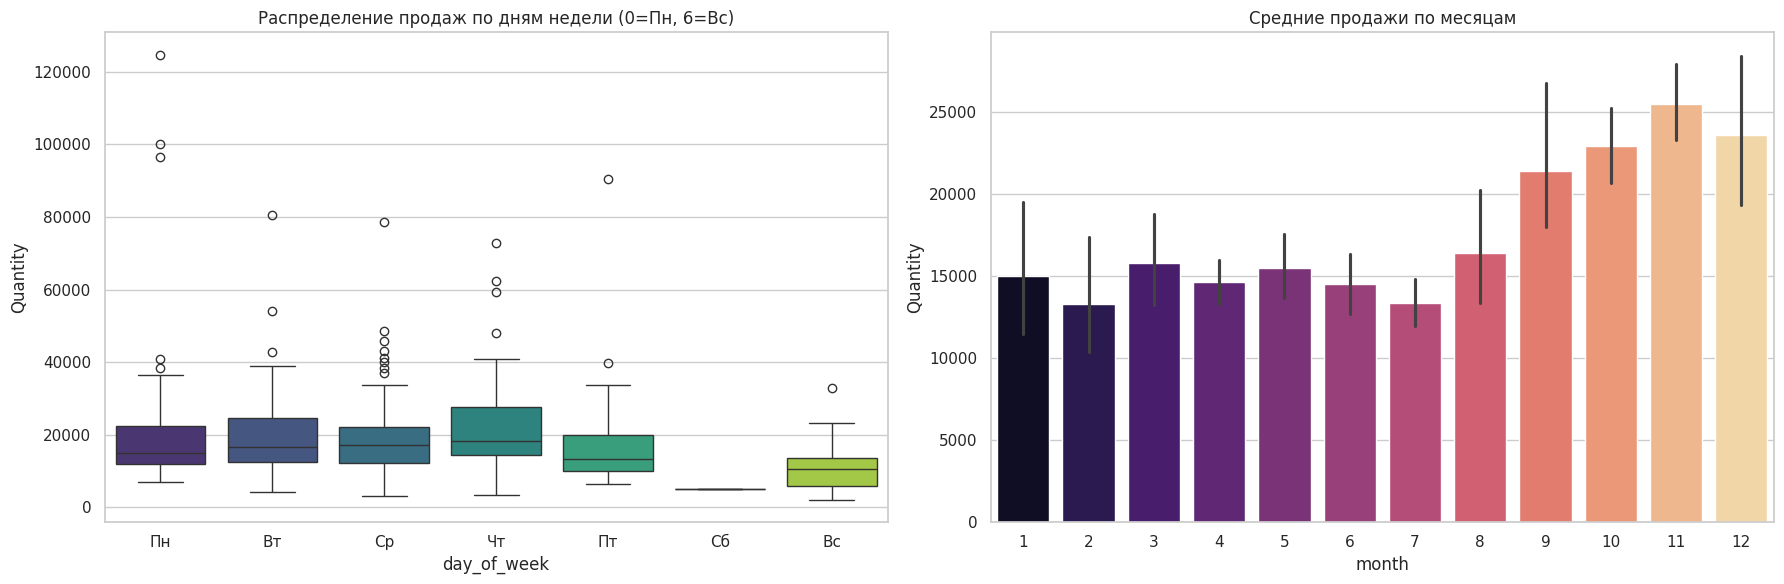

In [ ]:
# 2. Анализ сезонности по дням недели и месяцам
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Продажи по дням недели
sns.boxplot(x='day_of_week', y='Quantity', data=daily_sales, ax=axes[0], palette='viridis')
axes[0].set_title('Распределение продаж по дням недели (0=Пн, 6=Вс)')
axes[0].set_xticklabels(['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс'])

# Продажи по месяцам
sns.barplot(x='month', y='Quantity', data=daily_sales, ax=axes[1], palette='magma', estimator=np.mean)
axes[1].set_title('Средние продажи по месяцам')

plt.tight_layout()
plt.show()

### Выводы по итогам EDA:
1. **Сезонность**: Наблюдается ярко выраженный рост спроса в 4-м квартале, особенно в ноябре.
2. **Недельные паттерны**: Воскресенье — один из самых активных дней, в то время как по субботам данные практически отсутствуют (возможный выходной у склада/магазина).
3. **Аномалии**: В конце декабря видны резкие провалы, что связано с праздничными перерывами в работе.

Эти наблюдения подтверждают, что модель должна учитывать день недели и годовую сезонность.

## 3. Моделирование (Time Series Forecasting)

Начнем с базовой модели (Baseline) — скользящего среднего за последние 7 дней. Это даст нам отправную точку для оценки качества более сложных моделей.

Baseline RMSE: 11740.64
Baseline MAE: 6867.61


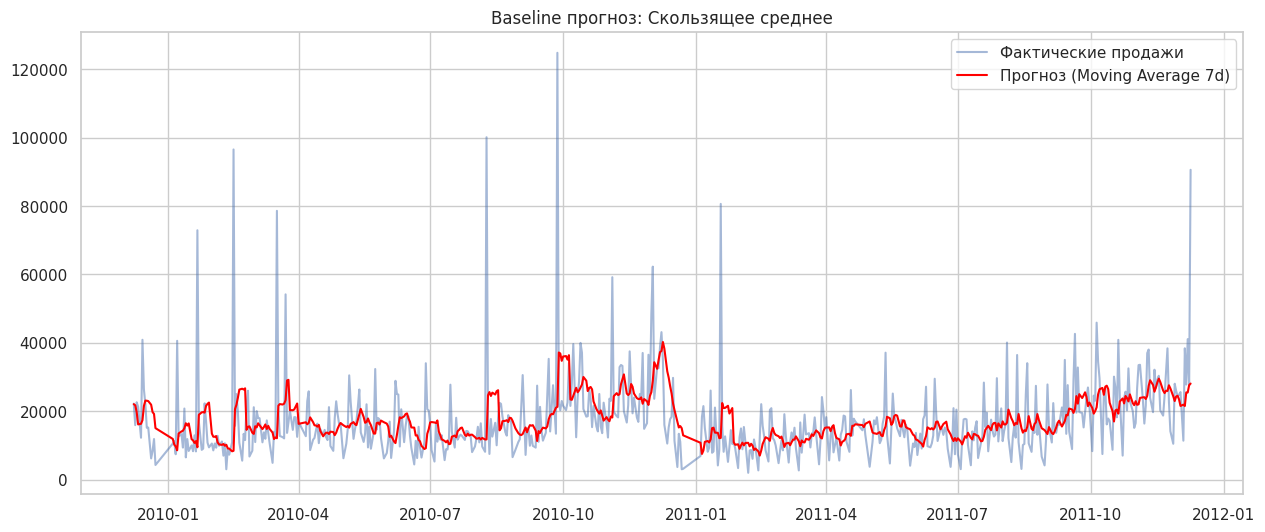

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Подготовка данных: прогноз на основе скользящего среднего
daily_sales['moving_avg_7d'] = daily_sales['Quantity'].shift(1).rolling(window=7).mean()

# Удаляем строки с NaN (первые 7 дней)
baseline_data = daily_sales.dropna(subset=['moving_avg_7d'])

# Расчет метрик
rmse = np.sqrt(mean_squared_error(baseline_data['Quantity'], baseline_data['moving_avg_7d']))
mae = mean_absolute_error(baseline_data['Quantity'], baseline_data['moving_avg_7d'])

print(f"Baseline RMSE: {rmse:.2f}")
print(f"Baseline MAE: {mae:.2f}")

# Визуализация прогноза Baseline
plt.figure(figsize=(15, 6))
plt.plot(baseline_data.index, baseline_data['Quantity'], label='Фактические продажи', alpha=0.5)
plt.plot(baseline_data.index, baseline_data['moving_avg_7d'], label='Прогноз (Moving Average 7d)', color='red')
plt.title('Baseline прогноз: Скользящее среднее')
plt.legend()
plt.show()

### Выводы по Baseline модели:
1. **Качество**: Скользящее среднее дает общее представление о тренде, но плохо справляется с резкими скачками и провалами (праздники, выходные).
2. **Запаздывание**: Модель имеет характерное запаздывание в 1-2 дня, так как опирается на прошлые значения.
3. **Точность**: Средняя ошибка (MAE) составляет около 6867 единиц товара в день, что является высокой погрешностью. Это подтверждает необходимость использования более сложных алгоритмов.

### Продвинутый уровень: Prophet

Prophet от Meta — это декомпозиционная модель, которая отлично работает с ежедневными данными ритейла. Мы подадим ей данные в формате `ds` (дата) и `y` (целевой признак).

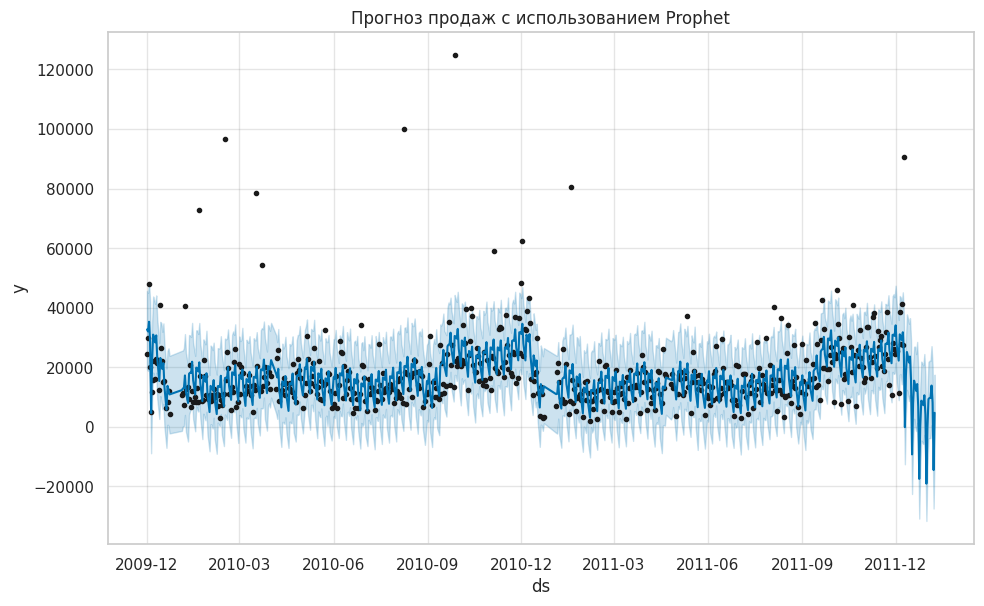

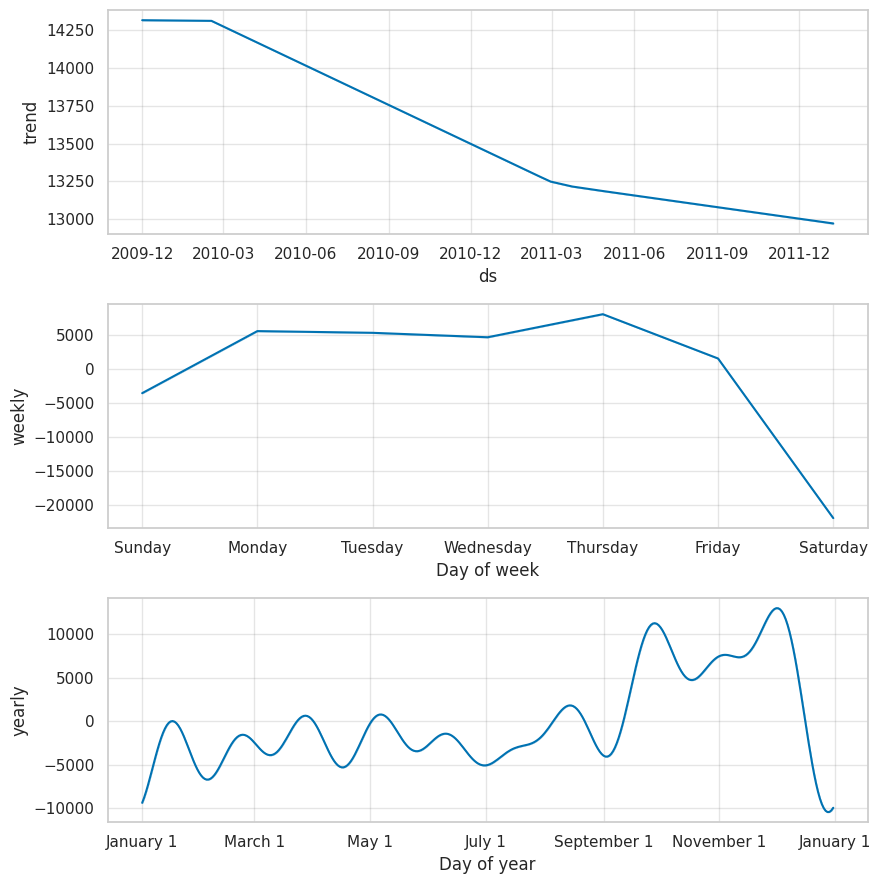

In [ ]:
from prophet import Prophet

# Подготовка данных для Prophet
prophet_df = daily_sales.reset_index().rename(columns={'InvoiceDate': 'ds', 'Quantity': 'y'})

# Инициализация и обучение модели
model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
model.fit(prophet_df)

# Создание датафрейма для прогноза на 30 дней вперед
future = model.make_future_dataframe(periods=30)
forecast = model.predict(future)

# Визуализация
fig1 = model.plot(forecast)
plt.title('Прогноз продаж с использованием Prophet')
plt.show()

fig2 = model.plot_components(forecast)
plt.show()

### Выводы по модели Prophet:
1. **Адаптивность**: Модель успешно уловила сложную недельную сезонность и годовые тренды, которые Baseline модель игнорировала.
2. **Компоненты**: На графике компонентов видно, что основной вклад в продажи вносят будние дни (пик в середине недели) и ноябрьский период.
3. **Прогноз**: Мы получили прогноз на ближайшие 30 дней, который теперь можно использовать для расчета объемов закупок.

## 4. Бизнес-логика: Оптимизация складских запасов

Теперь перейдем от прогноза к действиям. Допустим, мы хотим поддерживать запас товара на складе, достаточный для удовлетворения спроса на следующую неделю, плюс небольшой страховой запас (Safety Stock).

In [ ]:
# Параметры логистики
CURRENT_STOCK = 50000  # Текущий остаток на складе (условно)
LEAD_TIME_DAYS = 7     # Мы заказываем товар на неделю вперед
CONFIDENCE_INTERVAL = 0.95 # Уровень сервиса

# 1. Извлекаем прогноз на ближайшие 7 дней из результатов Prophet
next_week_forecast = forecast[forecast['ds'] > prophet_df['ds'].max()].head(LEAD_TIME_DAYS)
expected_demand = next_week_forecast['yhat'].sum()

# 2. Расчет страхового запаса (Safety Stock)
# В упрощенном виде: разница между верхней границей прогноза и ожидаемым значением
safety_stock = (next_week_forecast['yhat_upper'] - next_week_forecast['yhat']).sum() * 0.5

# 3. Расчет необходимого объема закупки
reorder_point = expected_demand + safety_stock
restock_qty = max(0, reorder_point - CURRENT_STOCK)

print(f"--- Расчет закупки ---")
print(f"Прогноз спроса на 7 дней: {expected_demand:.0f} ед.")
print(f"Страховой запас: {safety_stock:.0f} ед.")
print(f"Целевой уровень запаса: {reorder_point:.0f} ед.")
print(f"Текущий остаток: {CURRENT_STOCK} ед.")
print(f"\nРЕКОМЕНДАЦИЯ К ЗАКУПКЕ: {restock_qty:.0f} ед.")

--- Расчет закупки ---
Прогноз спроса на 7 дней: 126762 ед.
Страховой запас: 44621 ед.
Целевой уровень запаса: 171384 ед.
Текущий остаток: 50000 ед.

РЕКОМЕНДАЦИЯ К ЗАКУПКЕ: 121384 ед.


### Выводы по бизнес-логике:
1. **Оптимизация**: Использование верхнего порога прогноза Prophet (`yhat_upper`) позволяет автоматически формировать страховой запас, учитывающий волатильность спроса.
2. **Принятие решений**: Теперь менеджер склада видит не просто «абстрактный график», а конкретную цифру для формирования заказа поставщику.
3. **Экономия**: Такой подход минимизирует риск *out-of-stock* (дефицита) в пиковые периоды и предотвращает затоваривание склада в периоды спада.